# K-Means (평균을 이용한 군집화)

1. 개념
    - k개의 그룹으로 자동 분류하는 비지도 학습 알고리즘
    - 종속변수가 존재하지 않는 데이터에서 유사한 데이터들끼리의 모음
    - 서로 가까운 데이터는 같은 그룹으로 묶어서 그룹화
    - 그룹의 중심점을 반복적으로 계산해서 군집을 형성
2. 작업의 순서
    - 초기의 중심점(k개)을 선택
    - 각각의 데이터들을 중심점과의 거리를 확인
    - 가까운 거리를 중심점으로 할당
    - 각 군집의 평균을 구해서 새로운 중심점을 설정
    - 중심점의 변화가 거의 없을 때까지 반복 실행
3. 장단점
    - 장점 : 빠르고 단순하여 대용량의 데이터에 적합
    - 단점 : 군집의 수를 미리 알고 작성해야함, 이상치 민감
4. 매개변수
    - n_clusters
        - 기본값 : 8
        - 군집의 개수를 지정
        - 너무 적거나 크면 성능의 저하 가능
    - init
        - 기본값 : 'k-means++'
        - 초기의 중심점의 설정 방법
        - 기본값을 사용하면 빠르고 안정적
        - 'random'은 중심점 무작위 선택
    - n_init
        - 기본값 : 'auto'
        - 초기화 여러번 시도하여 최적의 결과를 선택
        - 값이 클수록 안정적이지만 시간은 증가
    - max_iter
        - 기본값 : 300
        - 한번의 실행에서 최대의 반복 횟수
        - 일반적을 300-500 사용
    - tol
        - 기본값 :  1e-4
        - 중심점의 이동의 변화량이 이 값보다 작은 경우에는 수렴
        - 값이 작을수록 정확하지만 시간은 증가
    - algorithm
        - 기본값 : 'lloyd'
        - K-Means의 계산 방법
        - 'elkan' -> 속도 향상(밀집 데이터에서 유리)
5. 속성
    - cluster_centers_
        - 각 군집의 중심점 좌표
    - labels_
        - 각 데이터의 군집의 번호
    - inertia_
        - 군집 내의 거리 제곱합
        - 작을수록 군집이 응집되어있음을 의미
    - n_iter_
        - 마지막 반복에서의 수행 횟수
6. 메서드
    - fit()
        - 모델의 학습
    - predict()
        - 새로운 데이터를 받아서 어떤 군집에 속하는지 예측
    - fit_predict()
        - 학습과 예측을 동시에 작업
    - transform()
        - 각 데이터와 각 중심점 간의 거리를 행렬로 반환
    - fit_transform()  
        - 적합 + 거리행렬 반환
    - score()
        - inertia_ 값을 반환 (값이 클수록 군집의 품질이 높다)
    - get_params() / set_params()
        - 사용한 매개변수의 확인 및 변경 (GridSearchCV에서 사용)
7. 검증
    - inertia
        - 군집 내의 거리 제곱합 (작을수록 응집)
    - silhouette_score
        - 응집도 + 분리도 의 종합 점수 (1에 가까울수록 좋음)
    - calinski_harabasz_score
        - 군집 간의 분산 / 군집 내의 분산 비율(높을수록 좋음)
    - davies_bouldin_score
        - 군집 간의 유사도 평균 (낮을수록 좋음)
    - adjusted_rand_score
        - 실제의 라벨과 군집의 일치도 (1 = 일치, 0 = 무작위)
    - nomalized_mutual_info
        - 정보이론적 일치도 (1 = 일치, 0 = 무관)

In [ ]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import pandas as pd
from sklearn.metrics import  silhouette_score, calinski_harabasz_score, \
    davies_bouldin_score, adjusted_rand_score, normalized_mutual_info_score

In [ ]:
iris = pd.read_csv('../data_git/data/iris.csv')
# 독립변수
x = iris.drop('target', axis=1).values
# 종속변수 (실제 라벨 데이터 - 검증에서 사용할 용도)
y = iris['target'].values

In [ ]:
# KMeans 모델을 생성
model = KMeans(
    n_clusters = 3,
    random_state = 42,
    n_init = 10,
)

In [ ]:
# 군집화는 일반적으로 Scaler 사용
x_std = StandardScaler().fit_transform(x)

In [ ]:
# 모델에 학습
model.fit(x_std)
labels = model.predict(x_std)

In [ ]:
# 검증 지표를 계산하고 출력
# 군집 내의 거리의 제곱합
inertia = model.inertia_
silhouette = silhouette_score(x_std, labels)
calinski = calinski_harabasz_score(x_std, labels)
davies = davies_bouldin_score(x_std, labels)
# 실제 라벨과의 계산
ari = adjusted_rand_score(y, labels)
nmi = normalized_mutual_info_score(y, labels)

print("inertia : ", round(inertia, 3))
print("silhouette : ", round(silhouette, 3))
print("calinske : ", round(calinski, 3))
print("davies : ", round(davies, 3))
print("ARI : ", round(ari, 3))
print("NMI : ", round(nmi, 3))

In [ ]:
# 군집의 상황을 2차원 그래프로 시각화(PCA 사용)
pca = PCA(n_components=2)
# 스케일링 된 데이터를 학습 및 변환
x_pca = pca.fit_transform(x_std)
# 중심점을 pca를 이용하여 2차원 데이터로 변환
centers_pca = pca.transform(model.cluster_centers_)

plt.figure(figsize=(8, 6))
# 2차원으로 구성된 스케일링 데이터의 산점도
plt.scatter(
    x_pca[:, 0], x_pca[:, 1], c = labels, cmap ='viridis', s = 40, alpha = 0.7
)
# 2차원으로 구성된 중심점 데이터의 좌표 표시
plt.scatter(
    centers_pca[:, 0], centers_pca[:, 1], c = 'black', s = 100, marker = 'X', label = 'Center'
)
plt.legend()
plt.show()

In [ ]:
# bodyPerformance 데이터를 이용하여 KMeans 사용
df = pd.read_csv("../data_git/data/bodyPerformance.csv")

In [ ]:
df.head()

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
# 문자형 데이터를 숫자형으로 변환
# gender 컬럼의 데이터를 숫자형으로 변환
le = LabelEncoder()
df['gender'] = le.fit_transform(df['gender'])
df.head()

In [ ]:
df['gender'].value_counts()

In [ ]:
df.info()

In [ ]:
# 데이터프레임에서 문자열인 컬럼의 목록을 불러온다.
obj_cols = df.select_dtypes('object').columns.tolist()
obj_cols

In [ ]:
# obj_cols를 이용하여 반복문을 실행
for obj in obj_cols:
    # LabelEncoder을 생성
    le = LabelEncoder()
    # 각 컬럼의 데이터들을 LabelEncoder()를 이용하여 변환
    df[obj] = le.fit_transform(df[obj])

In [ ]:
df.head()

In [ ]:
# 독립변수, 종속변수 생성
X = df.drop('class', axis = 1)
Y = df['class']
# 스케일링
X_std = StandardScaler().fit_transform(X)

In [36]:
# 군집의 개수에 따른 검증 지표 확인
# 개수를 2개부터 10개까지 확인
# 검증 지표를 저장할 빈 리스트 생성
rows = []

for k in range(2, 11):
    # k : 군집의 개수
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    pred = km.fit_predict(X_std)

    iner = km.inertia_
    sil = silhouette_score(X_std, pred)
    cali = calinski_harabasz_score(X_std, pred)
    davies = davies_bouldin_score(X_std, pred)
    ari = adjusted_rand_score(Y, pred)
    nmi = normalized_mutual_info_score(Y, pred)

    row = {
        "K" : k,
        "inertia" : iner,
        "silhouette " : sil,
        "calinski" : cali,
        "davies" : davies,
        "ARI" : ari,
        "NMI" : nmi
    }
    rows.append(row)

In [41]:
scores = pd.DataFrame(rows)
scores.round(3)

,K,inertia,silhouette,calinski,davies,ARI,NMI
0,2,94111.889,0.339,7571.308,1.234,0.003,0.003
1,3,81849.876,0.239,5355.456,1.634,0.031,0.037
2,4,72519.293,0.219,4603.596,1.691,0.048,0.058
3,5,67011.915,0.186,4011.249,1.728,0.034,0.041
4,6,63907.427,0.161,3494.700,1.789,0.031,0.044
5,7,59958.131,0.164,3250.798,1.763,0.059,0.096
6,8,57796.112,0.157,2961.934,1.809,0.059,0.100
7,9,55667.374,0.145,2754.585,1.816,0.062,0.110
8,10,53927.816,0.142,2575.276,1.832,0.060,0.110


In [47]:
# 최적의 k값은 2, 원본의 class의 개수는 4
k_list = [2, 4]

final_scores = []

for k in k_list:
    km = KMeans(n_clusters=k, n_init = 10, random_state=42)
    pred = km.fit_predict(X_std)

    iner = km.inertia_
    sil = silhouette_score(X_std, pred)
    cali = calinski_harabasz_score(X_std, pred)
    davies = davies_bouldin_score(X_std, pred)
    row = {
        "K" : k,
        "inertia" : iner,
        "silhouette" : sil,
        "cali" : cali,
        "davies" : davies,
    }
    final_scores.append(row)

In [48]:
pd.DataFrame(final_scores)

,K,inertia,silhouette,cali,davies
0,2,94111.888894,0.339082,7571.307615,1.234227
1,4,72519.293260,0.218644,4603.595793,1.691045


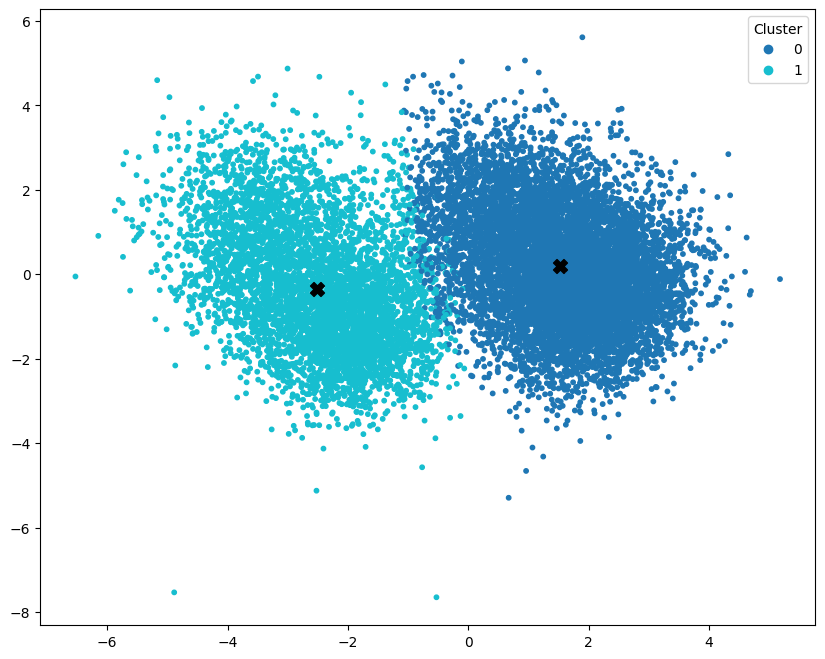

In [54]:
# 군집의 개수가 2인 경우 중심점과 데이터의 군집을 2차원 그래프로 확인
# PCA를 통해서 2차원으로 
pca = PCA(n_components=2, random_state=42)
x_pca = pca.fit_transform(X_std)

km_best = KMeans(n_clusters=2, n_init=10, random_state=42).fit(X_std)
# 군집의 번호를 출력
labels_best = km_best.labels_
# 군집의 중심점 좌표를 출력
center_best = km_best.cluster_centers_
# 중심점 2차원 차원 축소
center_pca = pca.transform(center_best)

plt.figure(figsize=(10,8))
# 2차원으로 축소한 데이터들의 분포
sc = plt.scatter(x_pca[:, 0], x_pca[:, 1], c = labels_best, s = 10, cmap = 'tab10')
# 중심점 좌표를 그래프에 추가
plt.scatter(center_pca[:, 0], center_pca[:, 1], c = 'black', s = 100, marker = 'X', label = 'Center')
plt.legend(*sc.legend_elements(), title = 'Cluster')

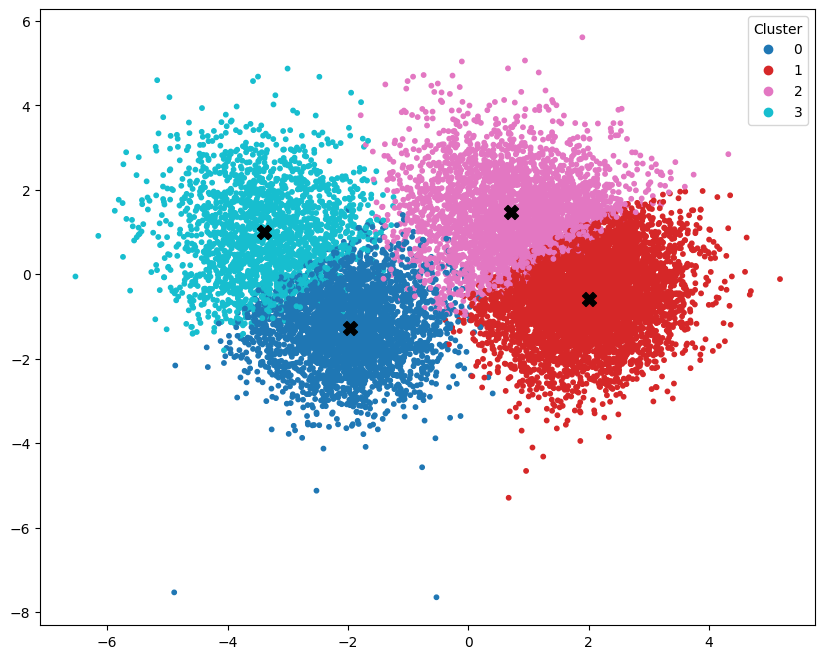

In [55]:
# 군집의 개수가 2인 경우 중심점과 데이터의 군집을 2차원 그래프로 확인
# PCA를 통해서 2차원으로 
pca = PCA(n_components=2, random_state=42)
x_pca = pca.fit_transform(X_std)

km_four = KMeans(n_clusters=4, n_init=10, random_state=42).fit(X_std)
# 군집의 번호를 출력
labels_best = km_four.labels_
# 군집의 중심점 좌표를 출력
center_best = km_four.cluster_centers_
# 중심점 2차원 차원 축소
center_pca = pca.transform(center_best)

plt.figure(figsize=(10,8))
# 2차원으로 축소한 데이터들의 분포
sc = plt.scatter(x_pca[:, 0], x_pca[:, 1], c = labels_best, s = 10, cmap = 'tab10')
# 중심점 좌표를 그래프에 추가
plt.scatter(center_pca[:, 0], center_pca[:, 1], c = 'black', s = 100, marker = 'X', label = 'Center')
plt.legend(*sc.legend_elements(), title = 'Cluster')

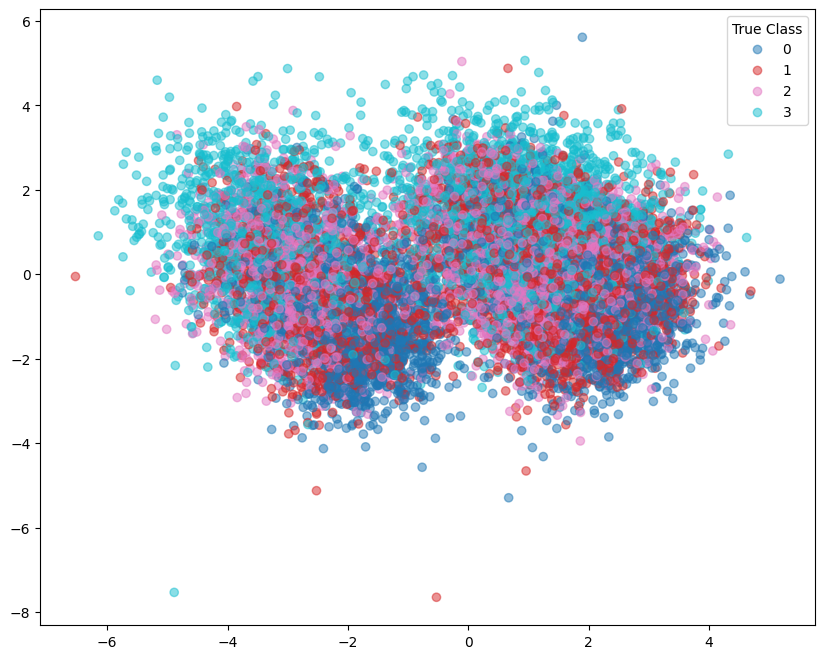

In [57]:
# 실제 class 별 데이터의 분포도를 확인
plt.figure(figsize=(10, 8))
sc_true= plt.scatter(
    x_pca[:, 0], x_pca[:, 1], c = Y, cmap = 'tab10', alpha=0.5
)
plt.legend(*sc_true.legend_elements(), title = 'True Class')
plt.show()

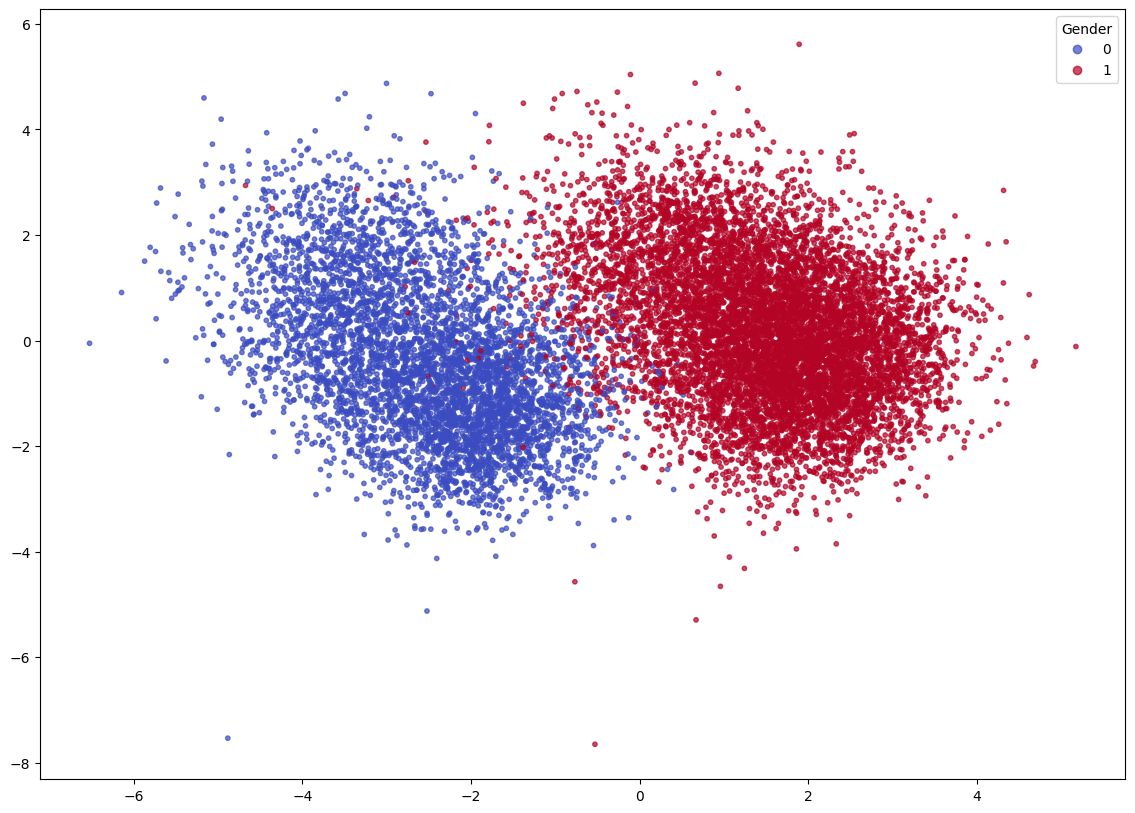

In [61]:
plt.figure(figsize=(14, 10))
sc_gender = plt.scatter(
    x_pca[:, 0], x_pca[:, 1],s = 10, alpha = 0.7, c = df['gender'].values, cmap='coolwarm'
)
plt.legend(*sc_gender.legend_elements(), title = 'Gender')
plt.show()